# Dinamik Ag Topolojilerinde A* Algoritmasi ile Oltalama Yayilim Analizi

Bu notebook, deney fisinde istenen bes fonksiyonu (update_alarm, dynamic_edge_cost,
dynamic_heuristic, discretize_alarm, astar_time_aware_dynamic) tamamlar ve
Statik A*, Naive Dynamic A* ile Time-Aware Dynamic A*'i ornek ag uzerinde
karsilastirir. S1-S12 senaryolarinin sonuclari `results.csv` dosyasindan okunur.

## 1. Ag verisi

Deney fisindeki 10 dugumlu ornek ag (Bolum 7-9).

In [1]:
import heapq
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

NODES = {
    "N01": {"segment": "DMZ",         "criticality": 2, "ids_coverage": 0.50},
    "N02": {"segment": "UserNet",     "criticality": 1, "ids_coverage": 0.30},
    "N03": {"segment": "AcademicNet", "criticality": 2, "ids_coverage": 0.40},
    "N04": {"segment": "AdminNet",    "criticality": 3, "ids_coverage": 0.60},
    "N05": {"segment": "FinanceNet",  "criticality": 4, "ids_coverage": 0.80},
    "N06": {"segment": "DMZ",         "criticality": 3, "ids_coverage": 0.55},
    "N07": {"segment": "ServerNet",   "criticality": 4, "ids_coverage": 0.70},
    "N08": {"segment": "AuthNet",     "criticality": 5, "ids_coverage": 0.95},
    "N09": {"segment": "AppNet",      "criticality": 5, "ids_coverage": 0.75},
    "N10": {"segment": "CoreNet",     "criticality": 5, "ids_coverage": 1.00},
}

EDGES = {
    "N01": {"N02": (1.5, 0, 0), "N03": (2.5, 0, 0)},
    "N02": {"N03": (2.0, 0, 0), "N06": (3.0, 0, 1)},
    "N03": {"N04": (3.0, 1, 1), "N07": (3.5, 1, 1)},
    "N04": {"N05": (2.5, 1, 1), "N08": (3.5, 1, 1), "N09": (3.0, 1, 0)},
    "N05": {"N08": (4.0, 1, 1), "N10": (6.0, 1, 1)},
    "N06": {"N07": (2.5, 1, 0)},
    "N07": {"N08": (3.0, 1, 1), "N10": (5.5, 1, 1)},
    "N09": {"N08": (2.0, 1, 0), "N10": (4.0, 1, 1)},
}
# deger sirasi: (base_cost, monitored, segment_jump)

ZONE_SENSITIVITY = {
    "DMZ": 0.40, "UserNet": 0.20, "AcademicNet": 0.30, "AdminNet": 0.50,
    "FinanceNet": 0.70, "ServerNet": 0.80, "AuthNet": 0.90, "AppNet": 0.60,
    "CoreNet": 1.00,
}

START, TARGET = "N02", "N10"
ALPHA, BETA, GAMMA, DELTA = 0.60, 0.20, 0.15, 0.10
LAMBDA, ETA = 1.5, 0.8
L0 = 0.10
Q_THRESHOLD, Q_MIN_CRIT, Q_PENALTY = 0.75, 4, 10.0

print("Dugum sayisi:", len(NODES), "| Kenar sayisi:", sum(len(v) for v in EDGES.values()))


Dugum sayisi: 10 | Kenar sayisi: 16


## 2. Eksik fonksiyonlarin tamamlanmasi (Adim 4)

In [2]:
def node_risk(node):
    n = NODES[node]
    crit_norm = (n["criticality"] - 1) / 4.0
    priv_norm = crit_norm
    return 0.4 * crit_norm + 0.3 * priv_norm + 0.3 * n["ids_coverage"]


def update_alarm(current_alarm, r_v, monitored, segment_jump):
    raw = ALPHA * current_alarm + BETA * r_v + GAMMA * monitored + DELTA * segment_jump
    return min(1.0, max(0.0, raw))

r_v = node_risk("N08")
print("R_v (N08) =", round(r_v, 3))
print("L0 =", L0, "-> yeni alarm =", round(update_alarm(L0, r_v, 1, 1), 4))


R_v (N08) = 0.985
L0 = 0.1 -> yeni alarm = 0.507


In [3]:
def dynamic_edge_cost(base_cost, target_node, current_alarm):
    ids_cov = NODES[target_node]["ids_coverage"]
    cost = base_cost * (1 + LAMBDA * current_alarm * ids_cov)
    if current_alarm > Q_THRESHOLD and NODES[target_node]["criticality"] >= Q_MIN_CRIT:
        cost += Q_PENALTY
    return cost

print("N05->N08 maliyeti (L_t=0.85):", round(dynamic_edge_cost(4.0, "N08", 0.85), 3))


N05->N08 maliyeti (L_t=0.85): 18.845


In [4]:
def hop_distance(target):
    rev = {n: [] for n in NODES}
    for u, neighbors in EDGES.items():
        for v in neighbors:
            rev[v].append(u)
    dist = {target: 0}
    frontier = [target]
    while frontier:
        nxt = []
        for u in frontier:
            for v in rev[u]:
                if v not in dist:
                    dist[v] = dist[u] + 1
                    nxt.append(v)
        frontier = nxt
    return dist

MIN_BASE_COST = min(c for edges in EDGES.values() for c, _, _ in edges.values())

def h_static(node, target, hop_table):
    if node == target:
        return 0.0
    if node not in hop_table:
        return math.inf
    return hop_table[node] * MIN_BASE_COST

def h_dynamic(node, target, current_alarm, hop_table):
    base = h_static(node, target, hop_table)
    if base == math.inf:
        return base
    zs = ZONE_SENSITIVITY[NODES[node]["segment"]]
    return base * (1 + ETA * current_alarm * zs)

hop_table = hop_distance(TARGET)
print("h_static(N04) =", round(h_static("N04", TARGET, hop_table), 3))
print("h_dynamic(N04, L=0.8) =", round(h_dynamic("N04", TARGET, 0.8, hop_table), 3))


h_static(N04) = 3.0
h_dynamic(N04, L=0.8) = 3.96


In [5]:
def discretize_alarm(alarm):
    bins = [0.20, 0.40, 0.60, 0.80, 1.01]
    for i, edge in enumerate(bins):
        if alarm <= edge:
            return i
    return len(bins) - 1

for a in [0.05, 0.25, 0.5, 0.7, 0.95]:
    print(f"L_t={a} -> alarm_bin={discretize_alarm(a)}")


L_t=0.05 -> alarm_bin=0
L_t=0.25 -> alarm_bin=1
L_t=0.5 -> alarm_bin=2
L_t=0.7 -> alarm_bin=3
L_t=0.95 -> alarm_bin=4


## 3. Model A - Statik A*

In [6]:
def astar_static(start, target):
    hop_table = hop_distance(target)
    def h(n):
        return h_static(n, target, hop_table)
    open_set = [(h(start), 0.0, start, [start])]
    best_g = {start: 0.0}
    closed = set()
    while open_set:
        f, g, node, path = heapq.heappop(open_set)
        if node in closed:
            continue
        closed.add(node)
        if node == target:
            return {"path": path, "cost": g}
        for neighbor, (base_cost, monitored, seg_jump) in EDGES.get(node, {}).items():
            new_g = g + base_cost
            if new_g < best_g.get(neighbor, math.inf):
                best_g[neighbor] = new_g
                heapq.heappush(open_set, (new_g + h(neighbor), new_g, neighbor, path + [neighbor]))
    return {"path": None, "cost": math.inf}

result_static = astar_static(START, TARGET)
print(result_static)


{'path': ['N02', 'N03', 'N07', 'N10'], 'cost': 11.0}


## 4. Model B - Naive Dynamic A* (kasitli eksik)

Durum sadece `node`, heuristik bir kere hesaplanip degismiyor, dugum yeniden acilmiyor.

In [7]:
def astar_naive_dynamic(start, target):
    hop_table = hop_distance(target)
    h_cache = {n: h_dynamic(n, target, L0, hop_table) for n in NODES}

    open_set = [(h_cache[start], 0.0, start, [start], L0)]
    best_g = {start: 0.0}
    closed = set()
    while open_set:
        f, g, node, path, alarm = heapq.heappop(open_set)
        if node in closed:
            continue
        closed.add(node)
        if node == target:
            return {"path": path, "cost": g, "final_alarm": alarm}
        for neighbor, (base_cost, monitored, seg_jump) in EDGES.get(node, {}).items():
            r_v = node_risk(neighbor)
            new_alarm = update_alarm(alarm, r_v, monitored, seg_jump)
            step_cost = dynamic_edge_cost(base_cost, neighbor, new_alarm)
            new_g = g + step_cost
            if neighbor in closed:
                continue
            if new_g < best_g.get(neighbor, math.inf):
                best_g[neighbor] = new_g
                heapq.heappush(open_set, (new_g + h_cache[neighbor], new_g, neighbor, path + [neighbor], new_alarm))
    return {"path": None, "cost": math.inf}

result_naive = astar_naive_dynamic(START, TARGET)
print(result_naive)


{'path': ['N02', 'N06', 'N07', 'N10'], 'cost': 18.808535, 'final_alarm': 0.72288}


## 5. Model C - Time-Aware Dynamic A* (dogru cozum)

Durum: `(node, step, alarm_bin)`.

In [8]:
def astar_time_aware_dynamic(start, target):
    hop_table = hop_distance(target)
    start_state = (start, 0, discretize_alarm(L0))
    counter = 0
    open_set = [(h_dynamic(start, target, L0, hop_table), 0.0, counter, start_state, [start], L0)]
    best_g = {start_state: 0.0}
    closed = set()
    while open_set:
        f, g, _, state, path, alarm = heapq.heappop(open_set)
        node, step, alarm_bin = state
        if state in closed:
            continue
        closed.add(state)
        if node == target:
            return {"path": path, "cost": g, "final_alarm": alarm, "steps": step}
        for neighbor, (base_cost, monitored, seg_jump) in EDGES.get(node, {}).items():
            r_v = node_risk(neighbor)
            new_alarm = update_alarm(alarm, r_v, monitored, seg_jump)
            step_cost = dynamic_edge_cost(base_cost, neighbor, new_alarm)
            new_g = g + step_cost
            new_state = (neighbor, step + 1, discretize_alarm(new_alarm))
            if new_state in closed:
                continue
            if new_g < best_g.get(new_state, math.inf):
                best_g[new_state] = new_g
                counter += 1
                heapq.heappush(open_set, (new_g + h_dynamic(neighbor, target, new_alarm, hop_table),
                                           new_g, counter, new_state, path + [neighbor], new_alarm))
    return {"path": None, "cost": math.inf}

result_dynamic = astar_time_aware_dynamic(START, TARGET)
print(result_dynamic)


{'path': ['N02', 'N06', 'N07', 'N10'], 'cost': 18.808535, 'final_alarm': 0.72288, 'steps': 3}


## 6. Bulunan yollarin karsilastirilmasi

Her modelin buldugu yolu, dogru dinamik IDS maliyet fonksiyonuyla yeniden hesaplayip adil bir karsilastirma yapiyoruz.

In [9]:
def true_path_cost(path, seed=1):
    rng = random.Random(seed)
    alarm = L0
    total = 0.0
    for u, v in zip(path[:-1], path[1:]):
        base_cost, monitored, seg_jump = EDGES[u][v]
        r_v = node_risk(v)
        alarm = update_alarm(alarm, r_v, monitored, seg_jump)
        total += dynamic_edge_cost(base_cost, v, alarm)
    return total

for name, res in [("Statik A*", result_static), ("Naive Dynamic A*", result_naive),
                   ("Time-Aware Dynamic A*", result_dynamic)]:
    tc = true_path_cost(res["path"])
    print(f"{name:24s} yol={'->'.join(res['path']):30s} gercek_maliyet={tc:.2f}")


Statik A*                yol=N02->N03->N07->N10             gercek_maliyet=18.90
Naive Dynamic A*         yol=N02->N06->N07->N10             gercek_maliyet=18.81
Time-Aware Dynamic A*    yol=N02->N06->N07->N10             gercek_maliyet=18.81


## 7. LLM cozumu (Model D / Model E)

`raw_llm_code.py` LLM'in urettigi ham koddur, `fixed_code.py` bizim duzelttigimiz halidir. Hata kayitlari `llm_error_log.xlsx` dosyasindadir.

In [10]:
import sys
sys.path.insert(0, ".")
from raw_llm_code import astar_llm_raw
from fixed_code import astar_dynamic as astar_llm_fixed

llm_graph = {}
for u, neighbors in EDGES.items():
    llm_graph[u] = {}
    for v, (base_cost, monitored, seg_jump) in neighbors.items():
        llm_graph[u][v] = {"base_cost": base_cost, "monitored": monitored}

raw_result = astar_llm_raw(llm_graph, START, TARGET)
fixed_result = astar_llm_fixed(START, TARGET)

print("LLM ham        ->", raw_result)
print("LLM duzeltilmis ->", fixed_result)


LLM ham        -> {'path': ['N02', 'N03', 'N07', 'N10'], 'cost': 17.2}
LLM duzeltilmis -> {'path': ['N02', 'N06', 'N07', 'N10'], 'cost': 18.808535, 'final_alarm': 0.72288, 'steps': 3}


## 8. S1-S12 senaryolarinin sonuclari

12 senaryo (dusuk/orta/yuksek/cok yuksek alarm volatilitesi, 20-150 dugumlu aglar), her biri 5 tekrarla calistirilip `results.csv` dosyasina yazilmistir.

In [11]:
results_df = pd.read_csv("results.csv")
results_df.head(15)


   scenario  n_nodes volatility  ...  optimality_gap_pct n_runs_found n_runs_total
0        S1       20      Dusuk  ...                0.17            5            5
1        S1       20      Dusuk  ...                0.00            5            5
2        S1       20      Dusuk  ...                0.00            5            5
3        S1       20      Dusuk  ...                0.46            5            5
4        S1       20      Dusuk  ...                0.00            5            5
5        S2       20       Orta  ...               20.96            5            5
6        S2       20       Orta  ...               -6.53            5            5
7        S2       20       Orta  ...                0.00            5            5
8        S2       20       Orta  ...               20.12            5            5
9        S2       20       Orta  ...                0.00            5            5
10       S3       20     Yuksek  ...                8.44            5            5
11  

In [12]:
summary = results_df.groupby("model_name")[["mean_true_cost", "optimality_gap_pct",
                                            "mean_expanded_nodes", "mean_runtime_sec"]].mean()
summary = summary.reindex(["Statik A*", "Naive Dynamic A*", "Time-Aware Dynamic A*",
                            "LLM (ham)", "LLM (duzeltilmis)"])
summary


                       mean_true_cost  ...  mean_runtime_sec
model_name                             ...                  
Statik A*                   54.805583  ...          0.000145
Naive Dynamic A*            47.039167  ...          0.000281
Time-Aware Dynamic A*       47.352500  ...          0.000307
LLM (ham)                   54.823000  ...          0.000073
LLM (duzeltilmis)           47.352500  ...          0.000307

[5 rows x 4 columns]

## 9. Grafikler

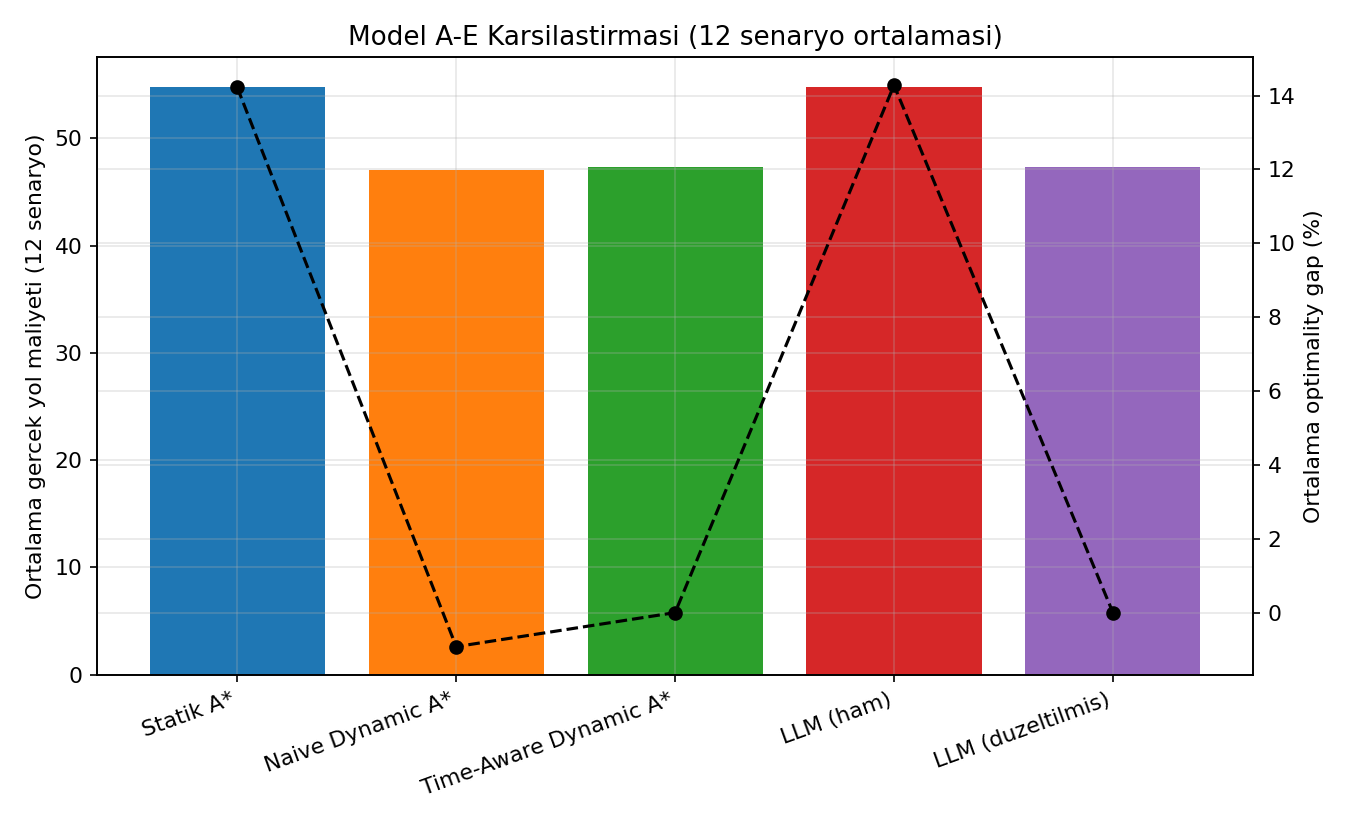

In [13]:
from IPython.display import Image
Image(filename="figures/2_model_karsilastirma.png")


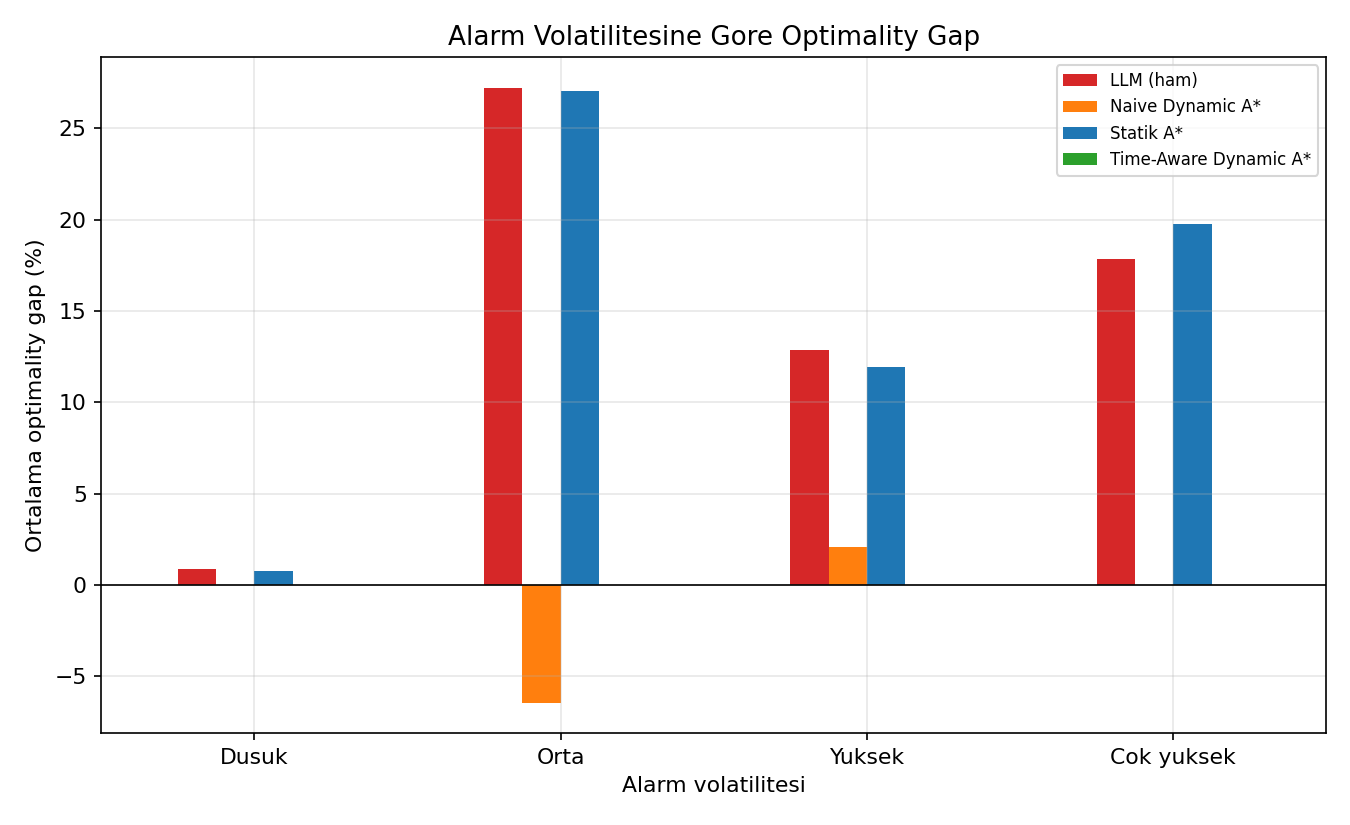

In [14]:
Image(filename="figures/4_volatilite_gap.png")


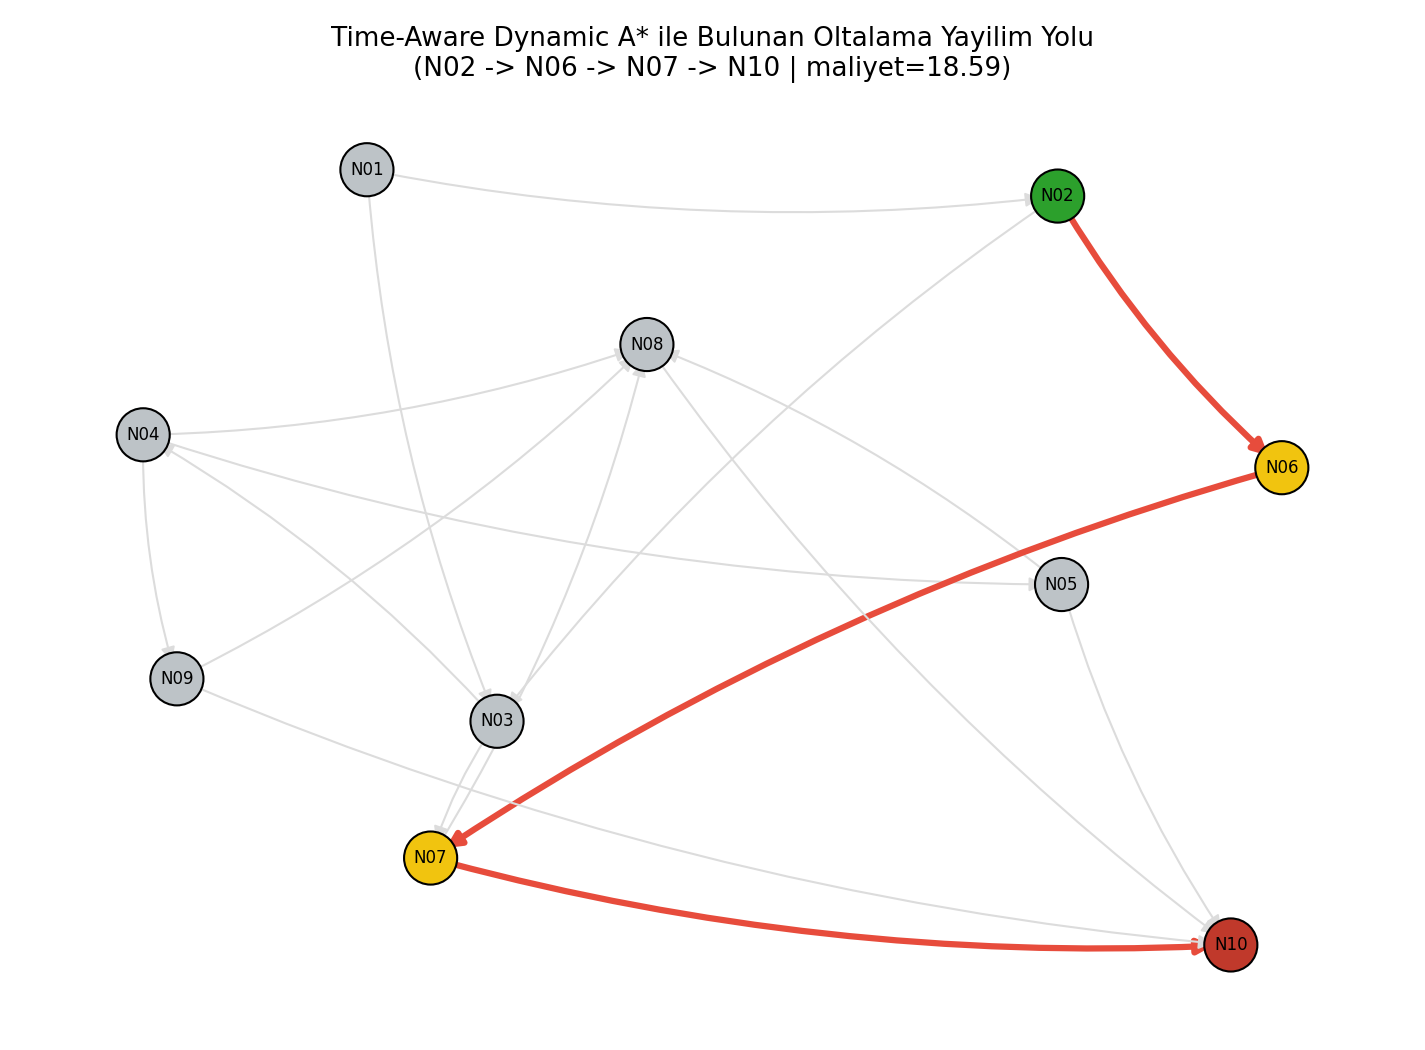

In [15]:
Image(filename="figures/7_ag_yol_gorsellestirme.png")


## 10. Sonuc

- Statik A*, dusuk volatiliteli senaryolarda (S1, S4, S7) makul sonuclar veriyor ama
  volatilite arttikca gercek maliyette buyuk sapmalar olusuyor (S12'de ~%23), cunku
  IDS etkisini hic hesaba katmiyor.
- Naive Dynamic A*, IDS maliyetini kismen hesaba katiyor fakat durum temsili sadece
  node oldugundan ve heuristigi guncellemedigi icin buyuk/yuksek volatiliteli aglarda
  (S9) Time-Aware Dynamic'e gore sapma gosteriyor.
- Time-Aware Dynamic A* (durum = node, step, alarm_bin), butun senaryolarda en dusuk
  veya en dusuklerden biri olan gercek maliyeti veriyor.
- LLM'in ham ciktisi, static heuristik ve yanlis durum temsili gibi hatalar icerdigi
  icin Statik A* ile benzer sekilde volatilite arttikca kotu performans gosteriyor;
  duzeltme sonrasi Time-Aware Dynamic A* ile ayni sonuca ulasiyor.